1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
hl = 3.052*60 #tempoem second
tl_atom = 1000
pb_atom = 0
step = 1
prob_decay = 1 - 2**(-1/hl)
t_max = 1000


tl_hist = []
pb_hist = []

In [3]:
#simulation
for t in range(t_max):
    tl_hist.append(tl_atom)
    pb_hist.append(pb_atom)

    decay = np.random.random(tl_atom) < prob_decay
    num_decay = np.sum(decay)

    tl_atom = tl_atom - num_decay
    pb_atom = pb_atom + num_decay

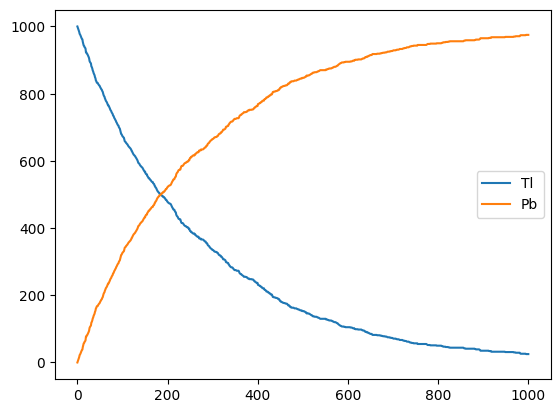

In [4]:
plt.plot(np.linspace(0,t_max,1000),tl_hist, label = 'Tl')
plt.plot(np.linspace(0,t_max,1000),pb_hist, label = 'Pb')
plt.legend()

Text(0, 0.5, 'Atoms that have not decayed')

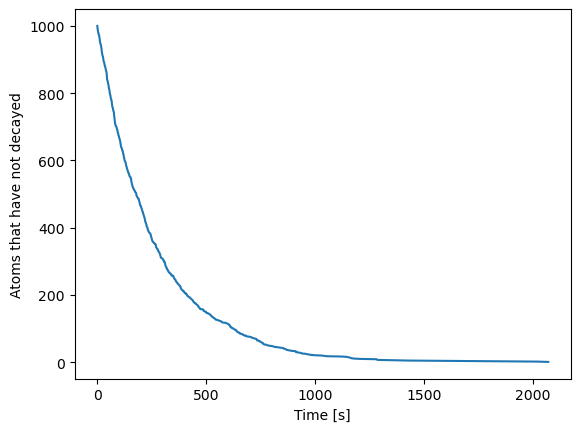

In [58]:
initial_atoms = 1000

u = np.random.rand(initial_atoms)
decay_times = -hl*np.log2(1-u)

decay_times = np.sort(decay_times)
atoms = np.arange(initial_atoms, 0, -1)

plt.plot(decay_times,atoms)
plt.xlabel('Time [s]')
plt.ylabel('Atoms that have not decayed')

2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [61]:
#constantes
a0 =  5.9e-11   
e  = 1.6e-19  
epsilon = 8.85e-12 

# parameters
E = 7.7*1e6*e # para que este en las unidades del SI    
Z = 79      
N = 1000000
sigma = a0/100

x = np.random.normal(0, sigma, N)
y = np.random.normal(0, sigma, N)
b = np.sqrt(x**2 + y**2) # distancia del origen al punto de impacto.

theta = 2*np.arctan( (Z*(e**2)) / (2*np.pi*epsilon*E*b) )
bounced_back =  np.sum(theta > np.pi/2)
print(bounced_back/N)

0.001276


3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere



In [90]:
def areacircle(N=100000):
    rng = np.random.default_rng()
    x = rng.uniform(-1,1,N)
    y = rng.uniform(-1,1,N)

    r2 = x**2 + y**2
    inside = np.sum(r2 <= 1)
    area_hat = 4.0 * inside / N
    # erro padrão (binomial) * volume da caixa
    p_hat = inside / N
    se = 4.0 * np.sqrt(p_hat * (1 - p_hat) / N)
    return area_hat, se

area, se = areacircle()
print(area, se)

3.1494 0.005175789447031245


In [100]:
def gen_area(N=1000000,seed=42,dim=10):
    rng = np.random.default_rng(seed)
    X_dim = rng.uniform(-1,1, size = (N,dim))
    r2 = np.sum(X_dim**2, axis=1)
    inside = np.sum(r2 <= 1.0)
    # Volume da hipercaixa
    box_vol = 2.0**dim

    # Estimativa Monte Carlo
    vol_hat = box_vol * inside / N

    # Erro estatístico
    p_hat = inside / N
    se = box_vol * np.sqrt(p_hat * (1 - p_hat) / N)

    return vol_hat, se

vol_hat, se = gen_area()
print(vol_hat, se)

2.540544 0.050941757843483024


5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [121]:
import numpy as np

def imp_sampling(N):
    u = np.random.uniform(0,1,N)
    x = u**2
    g = 1/(np.exp(x) + 1)
    C = 2

    imp = C*np.mean(g)
    return imp

imp_sampling(N=10000)

0.8399339431148152